In [1]:
# ============================================
# CELL 1 - Week 1 Checkpoint
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import torch
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("📋 WEEK 1 CHECKPOINT - PREDICTIVE MAINTENANCE PLATFORM")
print("="*60)
print("Checking all components...\n")

📋 WEEK 1 CHECKPOINT - PREDICTIVE MAINTENANCE PLATFORM
Checking all components...



In [2]:
# ============================================
# CELL 2 - Verify Database Connection
# ============================================
password = quote_plus("surya@2006")
engine   = create_engine(
    f"postgresql://postgres:{password}"
    f"@localhost:5432/predictive_maintenance"
)

print("🔄 Checking database...")

try:
    with engine.connect() as conn:
        # Check tables
        tables = conn.execute(text("""
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = 'public';
        """)).fetchall()

        print(f"✅ Database connected!")
        print(f"📊 Tables found: {[t[0] for t in tables]}")

        # Check row counts
        for table in [t[0] for t in tables]:
            count = conn.execute(
                text(f"SELECT COUNT(*) FROM {table};")
            ).fetchone()[0]
            print(f"   {table}: {count} rows")

except Exception as e:
    print(f"❌ Database error: {e}")

🔄 Checking database...
✅ Database connected!
📊 Tables found: ['anomalies', 'sensor_readings']
   anomalies: 0 rows
   sensor_readings: 20631 rows


In [4]:
# ============================================
# CELL 3 - Verify Dataset
# ============================================
print("🔄 Checking dataset...")

cols = ['engine_id', 'cycle'] + \
       [f'setting_{i}' for i in range(1, 4)] + \
       [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv(
    '../data/train_FD001.txt',
    sep='\s+',
    header=None,
    names=cols,
    engine='python'
)
train_df.dropna(axis=1, how='all', inplace=True)

# Add RUL
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df  = train_df.merge(max_cycle, on='engine_id')
train_df['RUL']           = train_df['max_cycle'] - train_df['cycle']
train_df['failure_label'] = (train_df['RUL'] < 30).astype(int)
train_df.drop(columns=['max_cycle'], inplace=True)

print(f"✅ Dataset loaded!")
print(f"📊 Shape          : {train_df.shape}")
print(f"📊 Engines        : {train_df['engine_id'].nunique()}")
print(f"📊 Total cycles   : {len(train_df)}")
print(f"📊 Normal samples : {(train_df['failure_label']==0).sum()}")
print(f"📊 Anomaly samples: {(train_df['failure_label']==1).sum()}")
print(f"📊 Missing values : {train_df.isnull().sum().sum()}")

🔄 Checking dataset...
✅ Dataset loaded!
📊 Shape          : (20631, 28)
📊 Engines        : 100
📊 Total cycles   : 20631
📊 Normal samples : 17631
📊 Anomaly samples: 3000
📊 Missing values : 0


In [6]:
# ============================================
# CELL 4 - Verify Saved Model
# ============================================
import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(hidden_dim, latent_dim, batch_first=True)
        self.decoder_lstm1 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(hidden_dim, input_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        enc1, _ = self.encoder_lstm1(x)
        enc1    = self.dropout(enc1)
        enc2, _ = self.encoder_lstm2(enc1)
        dec1, _ = self.decoder_lstm1(enc2)
        dec1    = self.dropout(dec1)
        dec2, _ = self.decoder_lstm2(dec1)
        return dec2

print("🔄 Checking saved model...")

try:
    sensor_cols = [f'sensor_{i}' for i in range(1, 22)
                   if f'sensor_{i}' in train_df.columns
                   and train_df[f'sensor_{i}'].std() > 0.001]

    model = LSTMAutoencoder(input_dim=len(sensor_cols))
    model.load_state_dict(
        torch.load('../models/lstm_autoencoder.pth',
                   map_location='cpu')
    )
    model.eval()
    print(f"✅ Model loaded successfully!")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📊 Total parameters: {total_params:,}")
    print(f"📊 Input features  : {len(sensor_cols)}")
except Exception as e:
    print(f"❌ Model error: {e}")

🔄 Checking saved model...
✅ Model loaded successfully!
📊 Total parameters: 63,228
📊 Input features  : 15


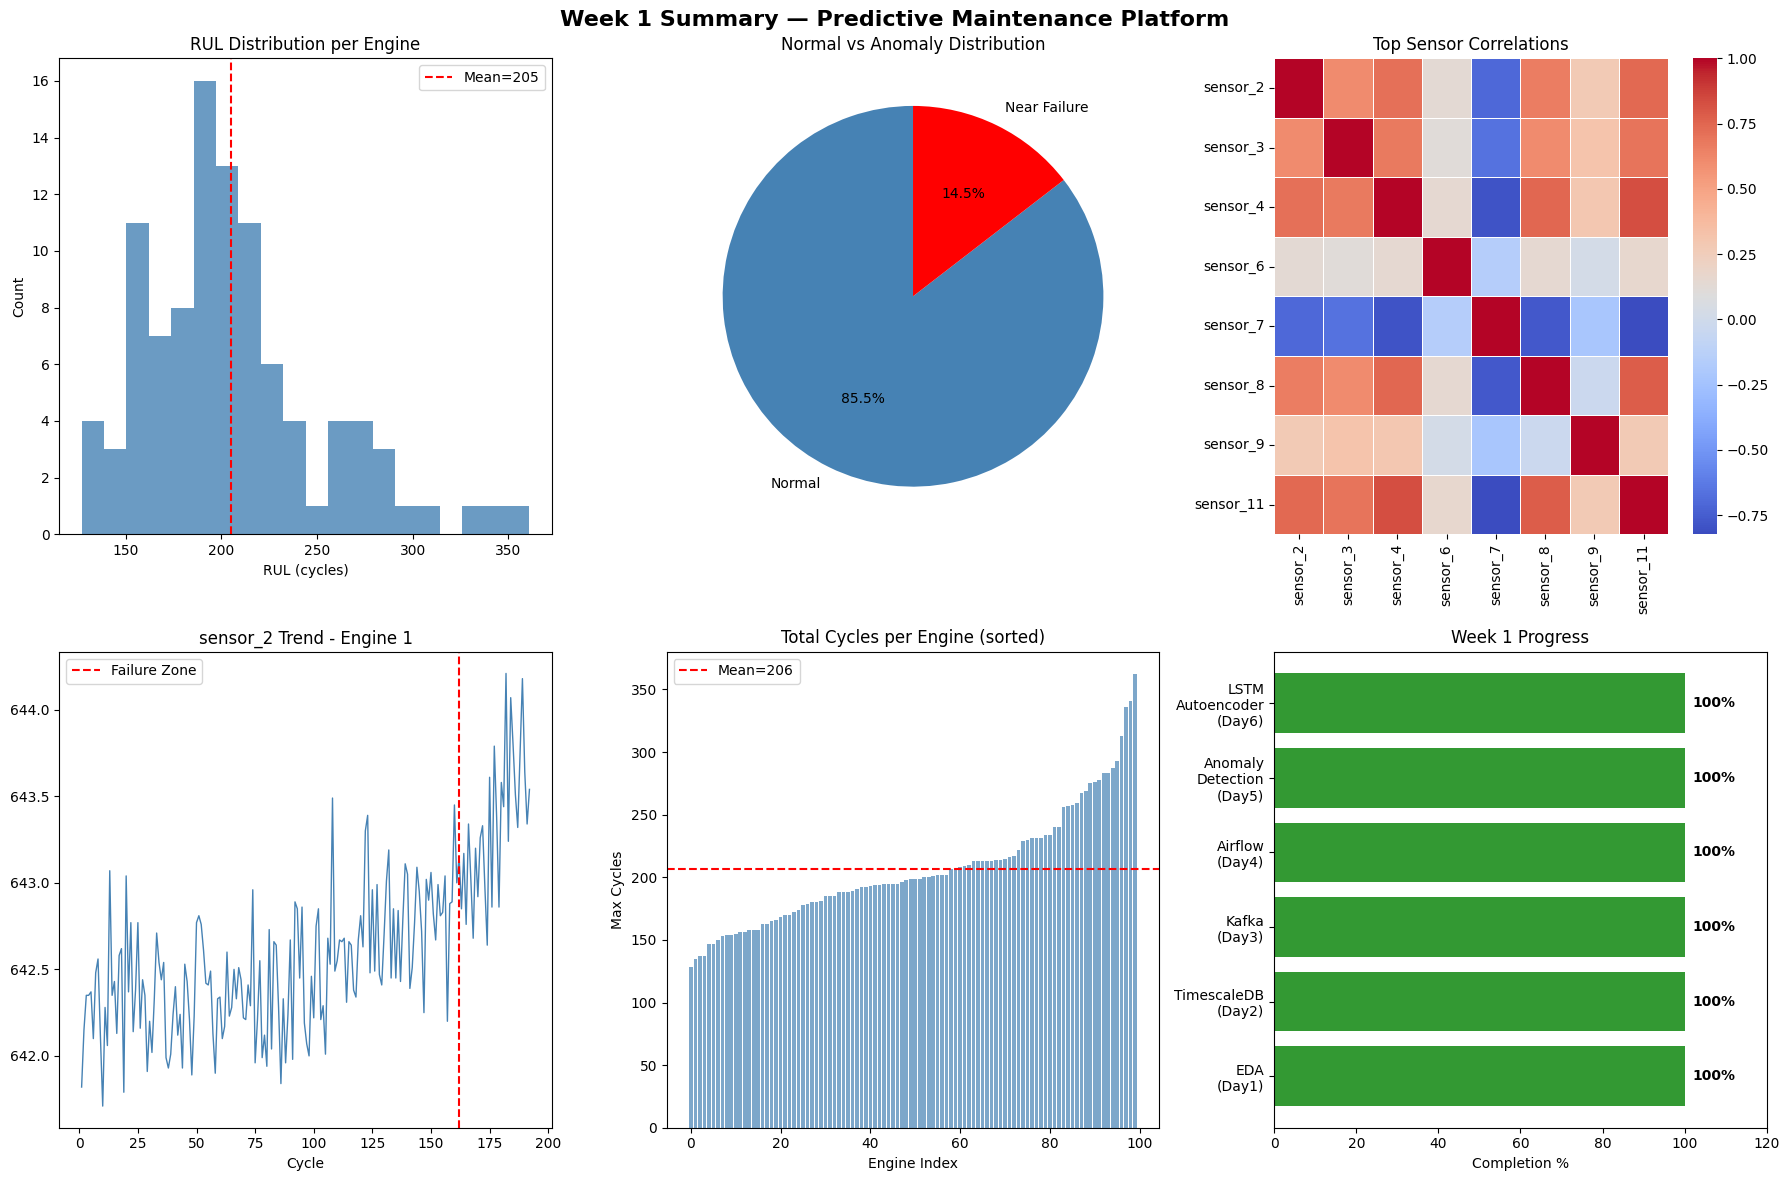

✅ Week 1 Dashboard saved!


In [8]:
# ============================================
# CELL 5 - Week 1 Summary Dashboard
# ============================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Week 1 Summary — Predictive Maintenance Platform',
             fontsize=16, fontweight='bold')

# Plot 1: RUL Distribution
ax1 = fig.add_subplot(2, 3, 1)
rul_per_engine = train_df.groupby('engine_id')['RUL'].max()
ax1.hist(rul_per_engine, bins=20, color='steelblue', alpha=0.8)
ax1.set_title('RUL Distribution per Engine')
ax1.set_xlabel('RUL (cycles)')
ax1.set_ylabel('Count')
ax1.axvline(rul_per_engine.mean(), color='red',
            linestyle='--', label=f'Mean={rul_per_engine.mean():.0f}')
ax1.legend()

# Plot 2: Failure Label Distribution
ax2 = fig.add_subplot(2, 3, 2)
labels       = ['Normal', 'Near Failure']
sizes        = [
    (train_df['failure_label']==0).sum(),
    (train_df['failure_label']==1).sum()
]
colors       = ['steelblue', 'red']
ax2.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Normal vs Anomaly Distribution')

# Plot 3: Sensor Correlation (top sensors)
ax3 = fig.add_subplot(2, 3, 3)
sensor_cols = [f'sensor_{i}' for i in range(1, 22)
               if f'sensor_{i}' in train_df.columns
               and train_df[f'sensor_{i}'].std() > 0.001]
top_sensors = sensor_cols[:8]
corr        = train_df[top_sensors].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm',
            ax=ax3, linewidths=0.5)
ax3.set_title('Top Sensor Correlations')

# Plot 4: Sensor Trend for Engine 1
ax4 = fig.add_subplot(2, 3, 4)
eng1 = train_df[train_df['engine_id'] == 1]
if sensor_cols:
    ax4.plot(eng1['cycle'], eng1[sensor_cols[0]],
             color='steelblue', linewidth=1)
    ax4.axvline(eng1['cycle'].max() - 30,
                color='red', linestyle='--',
                label='Failure Zone')
    ax4.set_title(f'{sensor_cols[0]} Trend - Engine 1')
    ax4.set_xlabel('Cycle')
    ax4.legend()

# Plot 5: Cycles per Engine
ax5 = fig.add_subplot(2, 3, 5)
cycles_per_engine = train_df.groupby('engine_id')['cycle'].max()
ax5.bar(range(len(cycles_per_engine)),
        sorted(cycles_per_engine.values),
        color='steelblue', alpha=0.7)
ax5.set_title('Total Cycles per Engine (sorted)')
ax5.set_xlabel('Engine Index')
ax5.set_ylabel('Max Cycles')
ax5.axhline(cycles_per_engine.mean(),
            color='red', linestyle='--',
            label=f'Mean={cycles_per_engine.mean():.0f}')
ax5.legend()

# Plot 6: Week 1 Progress
ax6 = fig.add_subplot(2, 3, 6)
tasks = [
    'EDA\n(Day1)',
    'TimescaleDB\n(Day2)',
    'Kafka\n(Day3)',
    'Airflow\n(Day4)',
    'Anomaly\nDetection\n(Day5)',
    'LSTM\nAutoencoder\n(Day6)'
]
completion = [100, 100, 100, 100, 100, 100]
colors_bar = ['green'] * 6
bars = ax6.barh(tasks, completion, color=colors_bar, alpha=0.8)
ax6.set_xlim(0, 120)
ax6.set_title('Week 1 Progress')
ax6.set_xlabel('Completion %')
for bar, val in zip(bars, completion):
    ax6.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/week1_summary_dashboard.png', dpi=150)
plt.show()
print("✅ Week 1 Dashboard saved!")

In [9]:
# ============================================
# CELL 6 - MLflow Experiments Summary
# ============================================
import mlflow

print("🔄 Checking MLflow experiments...")

try:
    client = mlflow.tracking.MlflowClient()
    experiments = client.search_experiments()

    print(f"✅ MLflow experiments found: {len(experiments)}")
    for exp in experiments:
        print(f"   📊 {exp.name}")

        runs = client.search_runs(exp.experiment_id)
        for run in runs:
            metrics = run.data.metrics
            params  = run.data.params
            model   = params.get('model', run.info.run_name)
            f1      = metrics.get('f1_score', 'N/A')
            auc     = metrics.get('roc_auc', 'N/A')
            print(f"      → {model}: F1={f1}, AUC={auc}")

except Exception as e:
    print(f"❌ MLflow error: {e}")

🔄 Checking MLflow experiments...
✅ MLflow experiments found: 2
   📊 anomaly_detection
      → LSTM_Autoencoder_Eval: F1=0.8024062933826932, AUC=0.9731042765583346
      → LSTM_Autoencoder: F1=N/A, AUC=N/A
      → LSTM_Autoencoder_Eval: F1=0.8027756360832691, AUC=0.972945096704668
      → LSTM_Autoencoder: F1=N/A, AUC=N/A
      → MAD: F1=0.4423571112095702, AUC=N/A
      → ZScore: F1=0.3012935975110529, AUC=N/A
      → LOF: F1=0.5902537485582469, AUC=0.8617797440114949
      → LOF: F1=0.5902537485582469, AUC=0.8617797440114949
      → IsolationForest: F1=0.7019849418206707, AUC=0.9468217722571987
      → IsolationForest: F1=0.7019849418206707, AUC=0.9468217722571987
      → IsolationForest: F1=N/A, AUC=N/A
   📊 Default


In [10]:
# ============================================
# CELL 7 - Final Week 1 Report
# ============================================

print("\n" + "="*60)
print("🏆 WEEK 1 FINAL REPORT")
print("="*60)

print("""
📅 WEEK 1 SUMMARY
─────────────────────────────────────────────────────────

DAY 1 ✅ Data Foundation
  • Dataset: NASA CMAPSS FD001
  • Engines: 100 | Cycles: 20,631
  • EDA: Correlation, FFT, Stationarity tests
  • Useful sensors identified: non-constant ones

DAY 2 ✅ TimescaleDB Setup
  • PostgreSQL 18 + TimescaleDB installed
  • Tables: sensor_readings, anomalies
  • Hypertable with 7-day chunks
  • 20,631 rows inserted

DAY 3 ✅ Kafka Simulator
  • Producer: streams sensor data
  • Consumer: reads & flags anomalies
  • Topics: raw-sensor-data, cleaned-features,
            anomalies-flagged

DAY 4 ✅ Airflow DAG Simulator
  • Task 1: Data Ingestion
  • Task 2: Data Validation
  • Task 3: Feature Engineering (rolling, lag, FFT)
  • Task 4: Write to PostgreSQL

DAY 5 ✅ Baseline Anomaly Detection
  • Isolation Forest
  • Local Outlier Factor (LOF)
  • Z-Score & MAD statistical methods
  • All logged to MLflow

DAY 6 ✅ Deep Learning Anomaly Detection
  • LSTM Autoencoder (PyTorch)
  • Trained on normal data only
  • Reconstruction error thresholding
  • Model saved to models/

─────────────────────────────────────────────────────────
""")

print("="*60)
print("✅ WEEK 1 COMPLETE! Ready for Week 2!")
print("="*60)


🏆 WEEK 1 FINAL REPORT

📅 WEEK 1 SUMMARY
─────────────────────────────────────────────────────────

DAY 1 ✅ Data Foundation
  • Dataset: NASA CMAPSS FD001
  • Engines: 100 | Cycles: 20,631
  • EDA: Correlation, FFT, Stationarity tests
  • Useful sensors identified: non-constant ones

DAY 2 ✅ TimescaleDB Setup
  • PostgreSQL 18 + TimescaleDB installed
  • Tables: sensor_readings, anomalies
  • Hypertable with 7-day chunks
  • 20,631 rows inserted

DAY 3 ✅ Kafka Simulator
  • Producer: streams sensor data
  • Consumer: reads & flags anomalies
  • Topics: raw-sensor-data, cleaned-features,
            anomalies-flagged

DAY 4 ✅ Airflow DAG Simulator
  • Task 1: Data Ingestion
  • Task 2: Data Validation
  • Task 3: Feature Engineering (rolling, lag, FFT)
  • Task 4: Write to PostgreSQL

DAY 5 ✅ Baseline Anomaly Detection
  • Isolation Forest
  • Local Outlier Factor (LOF)
  • Z-Score & MAD statistical methods
  • All logged to MLflow

DAY 6 ✅ Deep Learning Anomaly Detection
  • LSTM Autoe